In [9]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")

data = {
    'Category': ['Data Science', 'Software Engineer', 'Web Developer'] * 17,
    'Resume': [
        'Python developer with Django SQL ML experience',
        'Java developer Spring Boot microservices API',
        'React JavaScript HTML CSS frontend developer'
    ] * 17
}
df = pd.DataFrame(data)
df = df.rename(columns={'Resume': 'Resume_Text'})

df['Skills'] = df['Resume_Text']
df['Experience'] = np.random.randint(1, 10, size=len(df))

print("Sample dataset ready ✅ Shape:", df.shape)
df.head(3)

Sample dataset ready ✅ Shape: (51, 4)


,Category,Resume_Text,Skills,Experience
0,Data Science,Python developer with Django SQL ML experience,Python developer with Django SQL ML experience,1
1,Software Engineer,Java developer Spring Boot microservices API,Java developer Spring Boot microservices API,4
2,Web Developer,React JavaScript HTML CSS frontend developer,React JavaScript HTML CSS frontend developer,2


In [10]:
print("Duplicates:", df.duplicated(subset=['Resume_Text']).sum())
df = df.drop_duplicates(subset=['Resume_Text'], keep='first')
print("After removal:", df.shape)

Duplicates: 48
After removal: (3, 4)


In [11]:
df.isnull().sum()

Category       0
Resume_Text    0
Skills         0
Experience     0
dtype: int64

In [12]:
df = df.dropna(subset=['Resume_Text', 'Category'])
df['Skills'] = df['Skills'].fillna('Not Mentioned')
df['Experience'] = df['Experience'].fillna(df['Experience'].median())
print("Missing values after handling:")
df.isnull().sum()

Missing values after handling:


Category       0
Resume_Text    0
Skills         0
Experience     0
dtype: int64

In [13]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Cleaned_Resume'] = df['Resume_Text'].apply(clean_text)
df[['Resume_Text', 'Cleaned_Resume']].head(3)

,Resume_Text,Cleaned_Resume
0,Python developer with Django SQL ML experience,python developer with django sql ml experience
1,Java developer Spring Boot microservices API,java developer spring boot microservices api
2,React JavaScript HTML CSS frontend developer,react javascript html css frontend developer


In [14]:
df['Resume_Length'] = df['Cleaned_Resume'].apply(lambda x: len(x.split()))
df['Skills_Count'] = df['Skills'].apply(lambda x: len(str(x).split(',')) if x != 'Not Mentioned' else 0)
df['Experience_Bin'] = pd.cut(df['Experience'], bins=[0,2,5,10], 
                              labels=['0-2', '3-5', '6-10'])
df[['Resume_Length', 'Skills_Count', 'Experience_Bin']].head()

,Resume_Length,Skills_Count,Experience_Bin
0,7,1,0-2
1,6,1,3-5
2,6,1,0-2


In [15]:
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', max_df=0.9)
X_tfidf = tfidf.fit_transform(df['Cleaned_Resume'])
feature_names = tfidf.get_feature_names_out()
X_df = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)

df_features = pd.concat([df[['Category','Resume_Length','Skills_Count','Experience']].reset_index(drop=True), X_df], axis=1)
print("Feature matrix shape:", df_features.shape)

Feature matrix shape: (3, 19)


In [16]:
df.to_csv('cleaned_resumes.csv', index=False)
df_features.to_csv('feature_engineered_resumes.csv', index=False)
print("✅ Files saved: cleaned_resumes.csv + feature_engineered_resumes.csv")

✅ Files saved: cleaned_resumes.csv + feature_engineered_resumes.csv


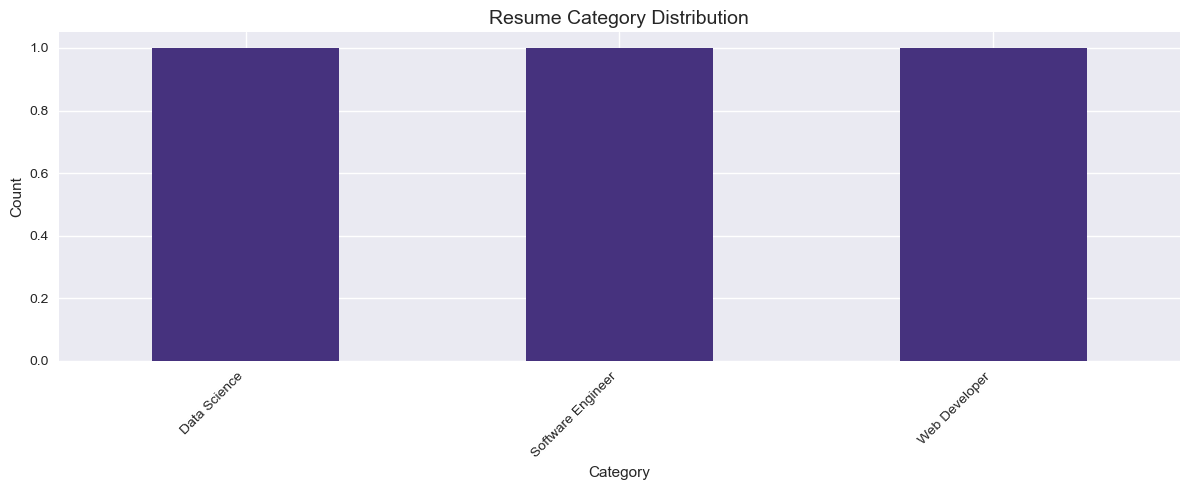

In [17]:
plt.figure(figsize=(12,5))
df['Category'].value_counts().plot(kind='bar')
plt.title('Resume Category Distribution', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('category_dist.png')
plt.show()

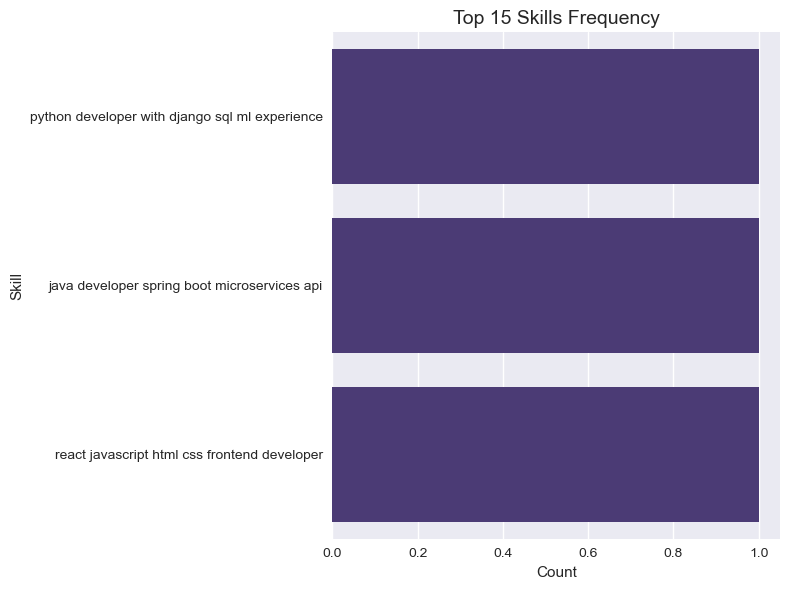

In [18]:
all_skills = ','.join(df['Skills'].dropna()).lower().split(',')
skill_counts = Counter([s.strip() for s in all_skills if s.strip() and s.strip() != 'not mentioned']).most_common(15)
skills_df = pd.DataFrame(skill_counts, columns=['Skill','Count'])

plt.figure(figsize=(8,6))
sns.barplot(data=skills_df, y='Skill', x='Count')
plt.title('Top 15 Skills Frequency', fontsize=14)
plt.tight_layout()
plt.savefig('skills_freq.png')
plt.show()

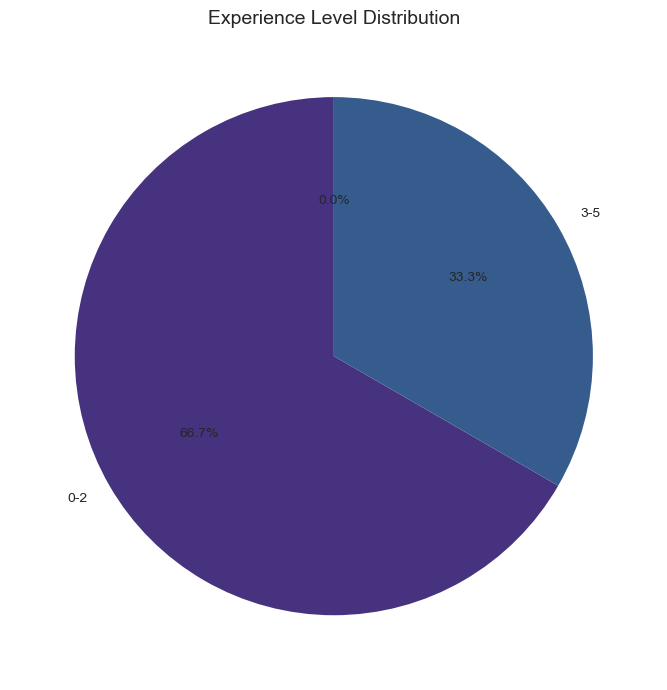

✅ Day 2 Complete! 3 files + 3 charts ready for submission


In [19]:
plt.figure(figsize=(7,7))
df['Experience_Bin'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Experience Level Distribution', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.savefig('experience_pie.png')
plt.show()

print("✅ Day 2 Complete! 3 files + 3 charts ready for submission")